# Обработка пропусков и дубликатов
**Цель работы:**
Научиться выявлять, анализировать и обрабатывать пропущенные значения и дубликаты в больших датасетах, используя библиотеки Pandas.

In [ ]:
import pandas as pd

df = pd.read_csv('employee_data.csv')

Объяснение столбцов:
```
'employee_id' : Номер сотрудника
'full_name': полное имя
'gender': пол
'birth_date': дата рождения
'hire_date': дата найма
'department': отдел
'position': должность
'salary': зарплата
'bonus': бонус
'experience_years': опыт
'projects completed': завершенные проекты
'city': город
'email': электронная почта
'phone': телефон
'performance score': оценка эффективности
'last_promotion_date': дата последняго дня продвижения
'vacation_days_used': дни отпуска использованы
'education_level': уровень образования
'certifications': количество сертификатов (повышение квалификации, курсы и т.д.)
'team_size': количество членов команды
```

# № 1. Первичный анализ данных

Необходимо исследовать структуру данных прежде чем выполнять обработку пропусков.

Необходимо вывести:
*   Первые 5 строк
*   Информация о столбцах
*   Статистика числовых столбцов
*   Статистика по категориальным столбцам

In [ ]:
# Напишите ваш код здесь

# Первые 5 строк
df.head(5)

,employee_id,full_name,gender,birth_date,hire_date,department,position,salary,bonus,experience_years,projects_completed,city,email,phone,performance_score,last_promotion_date,vacation_days_used,education_level,certifications,team_size
0,EMP06686,Volkova Anastasiya,Female,1998-11-21,2020-05-15 14:02:20.049925,Финансы,Lead,283000.0,26476.75,6.1,24.0,Москва,volkova.anastasiya@yandex.ru,NaN,4.3,NaN,14.0,Магистр,1.0,22.0
1,EMP09341,Tarasev Petr,Male,1978-01-05,2020-07-31 14:02:20.285656,Продажи,Senior,NaN,12634.84,6.0,16.0,Санкт-Петербург,petr23@yandex.ru,8 (955) 634-31-96,3.3,NaN,1.0,Кандидат наук,4.0,0.0
2,EMP05026,Orlov Andrey,Male,1991-03-04,2024-03-21 14:02:19.803175,R&D,Senior,118000.0,8935.17,2.3,12.0,Саратов,orlov.andrey@yandex.ru,некорректный номер,3.3,2025-03-21 14:02:19.803175,27.0,Магистр,2.0,0.0
3,EMP09705,Belyaeva Aleksandra,Female,1981-03-14,2013-09-16 14:02:20.306527,Консалтинг,Director,622000.0,99935.86,12.8,18.0,Санкт-Петербург,belyaevaa@yandex.ru,89682533660,4.7,2021-09-16 14:02:20.306527,20.0,Магистр,3.0,25.0
4,EMP06206,Sidorova Elena,Female,1980-05-03,2020-11-03 14:02:19.981862,Логистика,Lead,221000.0,18377.69,5.7,6.0,Москва,NaN,NaN,3.9,NaN,10.0,Бакалавр,4.0,9.0


In [ ]:
# Информация о столбцах
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employee_id          11500 non-null  object 
 1   full_name            11500 non-null  object 
 2   gender               11146 non-null  object 
 3   birth_date           11385 non-null  object 
 4   hire_date            11408 non-null  object 
 5   department           11230 non-null  object 
 6   position             11219 non-null  object 
 7   salary               11048 non-null  float64
 8   bonus                10861 non-null  float64
 9   experience_years     11500 non-null  float64
 10  projects_completed   10733 non-null  float64
 11  city                 11146 non-null  object 
 12  email                10727 non-null  object 
 13  phone                9573 non-null   object 
 14  performance_score    10383 non-null  float64
 15  last_promotion_date  4639 non-null  

In [ ]:
# Статистика числовых столбцов
df.describe().round(0)

,salary,bonus,experience_years,projects_completed,performance_score,vacation_days_used,certifications,team_size
count,11048.0,10861.0,11500.0,10733.0,10383.0,10874.0,10294.0,9034.0
mean,228202.0,24491.0,7.0,22.0,4.0,15.0,2.0,12.0
std,208372.0,26161.0,4.0,14.0,1.0,10.0,2.0,16.0
min,-986000.0,590.0,0.0,0.0,2.0,0.0,0.0,0.0
25%,89000.0,5887.0,3.0,11.0,3.0,7.0,1.0,0.0
50%,181000.0,15554.0,6.0,20.0,4.0,14.0,2.0,0.0
75%,315000.0,33914.0,10.0,32.0,4.0,22.0,4.0,25.0
max,5210000.0,213500.0,15.0,73.0,5.0,100.0,5.0,50.0


In [ ]:
df[df['salary'] < 0]
df['salary'] = abs(df['salary'])

In [ ]:
# Статистика по категориальным столбцам
df.describe(include=['object'])

,employee_id,full_name,gender,birth_date,hire_date,department,position,city,email,phone,last_promotion_date,education_level
count,11500,11500,11146,11385,11408,11230,11219,11146,10727,9573,4639,10791
unique,10000,1350,2,7041,9937,10,7,20,6680,8280,4219,5
top,EMP06397,Fedorov Sergey,Female,1972-10-16,2018-05-07 14:02:19.032820,Продажи,Senior,Москва,alekseevaa@yandex.ru,некорректный номер,2015-11-15 14:02:19.118161,Магистр
freq,2,20,5601,7,2,2754,2459,3243,13,159,2,3997


Вопросы:
1.   Сколько всего строк и столбцов в датасете?
2.   Какие типы данных присутствуют?
3.   Сколько числовых и сколько категориальных столбцов?

In [ ]:
df.shape

(11500, 20)

In [ ]:
df.dtypes.value_counts()

,count
object,12
float64,8


Анализ пропусков
* Создайте DataFrame с информацией о пропусках со следующей структурой:
```
'Тип данных'
'Всего значений'
'Пропущено'
'Процент пропусков'
```
* Визуализируйте пропуски:

Воспользуйтесь функцией bar

Название - Процент пропусков по столбцам

х - Процент пропусков по столбцам

у - Процент пропусков (%)


* Постройте матрицу пропусков (heatmap):

Название - Матрица пропусков (желтый = пропуск)

х - Столбцы

у - Строки (первые 1000)



In [ ]:
# Напишите ваш код здесь
missing_info = pd.DataFrame({
    'Тип данных': df.dtypes,
    'Всего значений': df.count(),
    'Пропущено': df.isnull().sum(),
    'Процент пропусков': ((df.isnull().sum() / len(df)) * 100).round(2)
})

missing_info

,Тип данных,Всего значений,Пропущено,Процент пропусков
employee_id,object,11500,0,0.00
full_name,object,11500,0,0.00
gender,object,11146,354,3.08
birth_date,object,11385,115,1.00
hire_date,object,11408,92,0.80
department,object,11230,270,2.35
position,object,11219,281,2.44
salary,float64,11048,452,3.93
bonus,float64,10861,639,5.56
experience_years,float64,11500,0,0.00


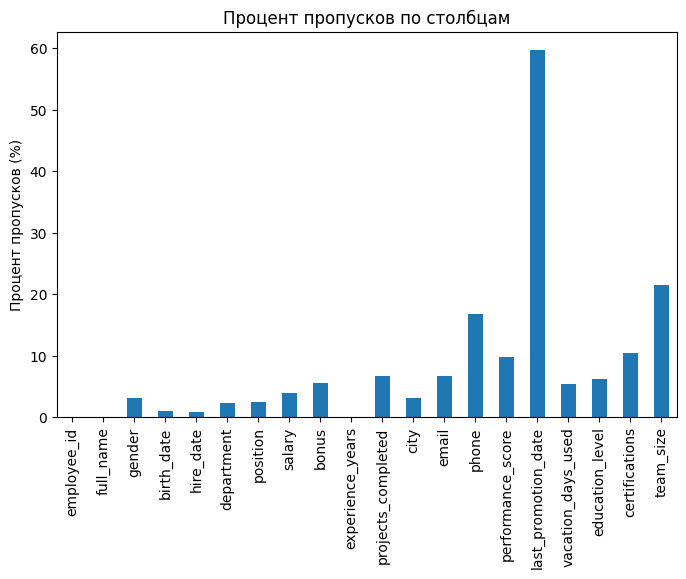

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
missing_info['Процент пропусков'].plot(kind='bar')
plt.title('Процент пропусков по столбцам')
plt.ylabel('Процент пропусков (%)')
plt.xticks(rotation=90)
plt.show()

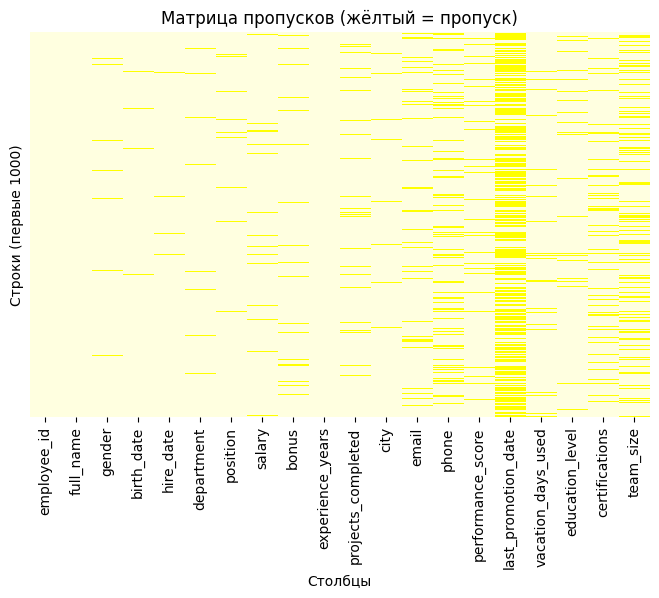

In [ ]:
import matplotlib.colors as mcolors

plt.figure(figsize=(8, 5))
sns.heatmap(df.head(1000).isnull(), cbar=False, yticklabels=False, cmap=mcolors.ListedColormap(["lightyellow", "yellow"]))
plt.title('Матрица пропусков (жёлтый = пропуск)')
plt.xlabel('Столбцы')
plt.ylabel('Строки (первые 1000)')
plt.show()

Вопросы:
1. В каких 3 столбцах наибольший процент пропусков?
2. Сколько строк не содержат ни одного пропуска?
3. Какой процент данных потеряется при удалении всех строк с пропусками?

In [ ]:
(df.isna().any(axis=1).sum() / df.shape[0] * 100).round(2)

np.float64(86.89)

# № 2. Обработка пропусков

* Удалите строки с любыми пропусками, отобразите:

Исходный размер:

Новый размер:

Потеря данных:




*   Удаление столбцов с большим процентом пропусков

threshold = 0.3  # 30%

Удалено столбцов:

Удаленные столбцы:

Новый размер:


*   Условное удаление строк

Удаляем строки, где пропущено более 50% столбцов

threshold_cols = int(len(df.columns) * 0.5)

* Удаление на основе важности столбцов

Определяем критически важные столбцы

critical_cols = ['employee_id', 'full_name', 'department', 'position', 'salary']


In [ ]:
# Удалите строки с любыми пропусками
df1 = df.dropna()

print("Исходный размер:", df.shape)
print("Новый размер:", df1.shape)
print(f"Потеря данных: {df.shape[0] - df1.shape[0]} строк - {(df.shape[0] - df1.shape[0]) / df.shape[0] * 100:.2f}%")

Исходный размер: (11500, 20)
Новый размер: (1508, 20)
Потеря данных: 9992 строк - 86.89%


In [ ]:
# Удаление столбцов с большим процентом пропусков (30%)
threshold = 0.30
df2 = df.dropna(thresh=len(df)*(1-threshold), axis=1)

print("Удалено столбцов:", df.shape[1] - df2.shape[1])
print("Удаленные столбцы:", set(df.columns) - set(df2.columns))
print("Новый размер:", df2.shape)

Удалено столбцов: 1
Удаленные столбцы: {'last_promotion_date'}
Новый размер: (11500, 19)


In [ ]:
# Условное удаление строк (пропущено > 50% столбцов)
threshold_cols = int(len(df.columns) * 0.5)
df3 = df.dropna(thresh=len(df.columns) - threshold_cols)

print("Новый размер:", df3.shape)

Новый размер: (11500, 20)


In [ ]:
# Удаление на основе важности столбцов
critical_cols = ['employee_id', 'full_name', 'department', 'position', 'salary']
df4 = df.dropna(subset=critical_cols)

print("Новый размер:", df4.shape)

Новый размер: (10517, 20)


Вопросы:
1. Какой метод удаления приводит к наименьшей потере данных?
2. Почему удаление столбцов может быть опасным?
3. В каких случаях стоит использовать стратегическое удаление?

> Стратегическое удаление нужно использовать, если пропуски находятся в критически важных для анализа столбцах, и их невозможно корректно заполнить

Заполнение пропусков

Заполнение константами для разных типов данных

1. Заполнение константами:

*Для категориальных данных* - **"Не указано"**

*Для числовых данных* - **-1**

*Для дат* - **'1900-01-01'**

2. Заполнение статистическими показателями:

*Для каждого числового столбца:*

Сильно асимметричное распределение - медиана

Более симметричное распределение - среднее

*Для категориальных - модой*

3. Групповое заполнение

Зарплата по позиции и городу

Бонус как процент от зарплаты


In [ ]:
# Напишите ваш код здесь
df_filled1 = df.copy()
df_filled2 = df.copy()
df_filled3 = df.copy()

# 1. Заполнение константами
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df_filled1[col] = df[col].fillna('Не указано')
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            df_filled1[col] = df[col].fillna('1900-01-01')
        else:
            df_filled1[col] = df[col].fillna(-1)

df_filled1.isnull().sum()

,0
employee_id,0
full_name,0
gender,0
birth_date,0
hire_date,0
department,0
position,0
salary,0
bonus,0
experience_years,0


In [ ]:
# 2. Заполнение статистическими показателями
for col in df.select_dtypes(include=['number']).columns:
    if df[col].isnull().any():
        if abs(df[col].skew()) > 1:
            df_filled2[col] = df[col].fillna(df[col].median())
        else:
            df_filled2[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include=['object', 'bool']).columns:
    if df[col].isnull().any():
        df_filled2[col] = df[col].fillna(df[col].mode()[0])

df_filled2.isnull().sum()

,0
employee_id,0
full_name,0
gender,0
birth_date,0
hire_date,0
department,0
position,0
salary,0
bonus,0
experience_years,0


In [ ]:
# 3. Групповое заполнение
df_filled3['salary_by_position_city'] = df.groupby(['position', 'city'])['salary'].transform(lambda x: x.fillna(x.median()))

df_filled3['bonus_pct'] = df['bonus'] / df['salary']
df_filled3['bonus_filled'] = df['bonus'].fillna(df['salary'] * df_filled3['bonus_pct'].median())


Вопросы:
1. Как выбрать между медианой и средним для заполнения?
2. Почему групповое заполнение часто лучше общего?
3. Какие риски у заполнения константами?

# № 3 Обработка дубликатов

Дубликаты могут быть 4-х типов:
*   Полные дубликаты
*   По employee_id
*   По ФИО и email
*   По основным атрибутам ('full_name', 'birth_date', 'city')

Стратегии обработки дубликатов
1. УДАЛЕНИЕ:
* Оставить первую запись
* Оставить последнюю запись
* Удалить все дубликаты

2. Удаление на основе дополнительных условий (например по дате найма)

In [ ]:
# Напишите ваш код здесь

print("Полных дубликатов:", df.duplicated().sum())
print("Дубликатов по employee_id:", df.duplicated(subset=['employee_id']).sum())
print("Дубликатов по ФИО и email:", df.duplicated(subset=['full_name', 'email']).sum())
print("Дубликатов по основным атрибутам:", df.duplicated(subset=['full_name', 'birth_date', 'city']).sum())

Полных дубликатов: 144
Дубликатов по employee_id: 1500
Дубликатов по ФИО и email: 3790
Дубликатов по основным атрибутам: 1369


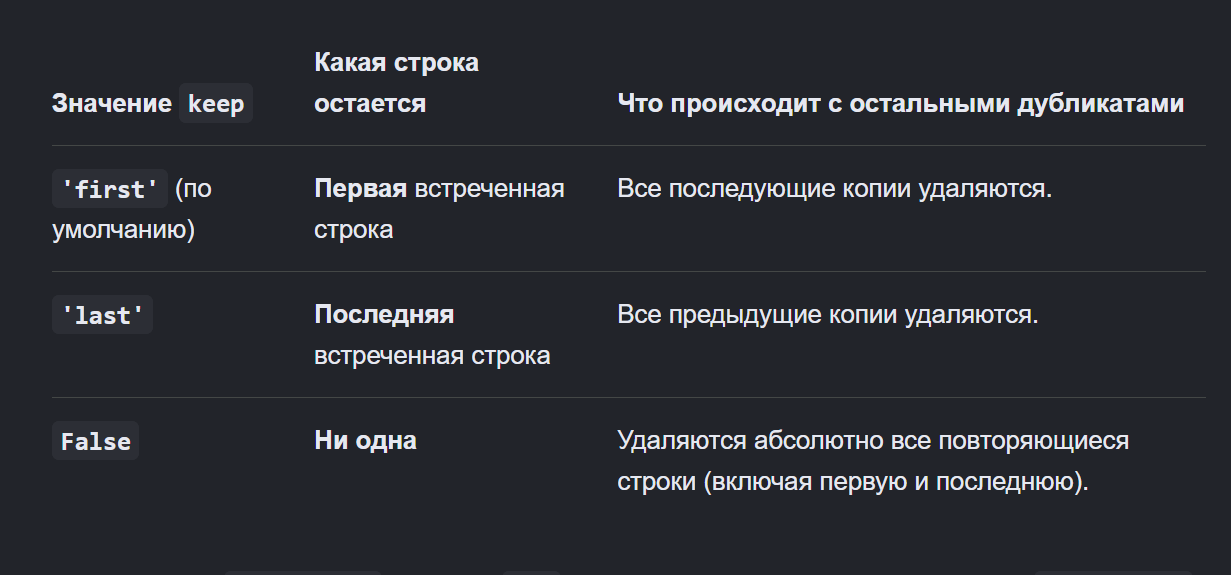

Вопросы:
1. Какая стратегия удаления сохраняет наибольшее количество данных?
2. Как выбрать между "первой" и "последней" записью?

# № 4 Практическое применение

Используя очищенные от ошибок и дубликатов данные, сделайте HR статистику:

1. Распределение сотрудников по департаментам
2. Распределение по позициям
3. Средние показатели по департаментам (зарплата, опыт, оценка эффективности, завершенные проекты)
4. Зарплаты по позициям
5. Связь зарплаты и эффективности
6. Эффективность по департаментам

Ключевые выводы для HR-отчета:
* Наиболее оплачиваемый департамент
* Самый эффективный департамент
* Департамент с наибольшим количеством проектов
* Самый опытный департамент
* Проблемные зоны  (Департамент, требующий внимания, низкая оценка)

*Визуализация для отчета (графики):
*   Распределение зарплат по департаментам (boxplot)
*   Зависимость зарплаты от опыта (scatter)
*   Распределение по городам (barh)



In [ ]:
# Напишите ваш код здесь
# выберем filled2 и очиску от дубликатов по employee_id

df_clean = df_filled2.drop_duplicates(subset=['employee_id']).copy()

In [ ]:
# 1. Распределение сотрудников по департаментам
df_clean['department'].value_counts()

,count
department,
Продажи,2637
IT,1664
Производство,1584
Маркетинг,994
Финансы,776
HR,661
Логистика,552
R&D,525
Юридический,399


In [ ]:
# 2. Распределение по позициям
df_clean['position'].value_counts()

,count
position,
Senior,2352
Lead,1944
Manager,1744
Middle,1529
Junior,1510
Director,712
Executive,209


In [ ]:
# 3. Средние показатели по департаментам
df_clean.groupby('department')[['salary', 'experience_years', 'performance_score', 'projects_completed']].mean().round(2)

,salary,experience_years,performance_score,projects_completed
department,,,,
HR,187125.57,6.45,3.82,21.41
IT,269337.74,6.71,3.81,22.17
R&D,264615.24,6.94,3.84,22.37
Консалтинг,246605.77,7.10,3.80,23.73
Логистика,204634.06,6.71,3.84,22.07
Маркетинг,217400.40,6.69,3.83,22.10
Продажи,236110.35,6.75,3.84,21.94
Производство,200139.52,6.58,3.80,21.16
Финансы,249421.39,6.98,3.83,22.96


In [ ]:
# 4. Зарплаты по позициям
df_clean.groupby('position')['salary'].mean().sort_values(ascending=False).round(2)

,salary
position,
Executive,819966.51
Director,560926.97
Manager,370974.77
Lead,244436.73
Senior,168360.54
Middle,91171.35
Junior,55289.40


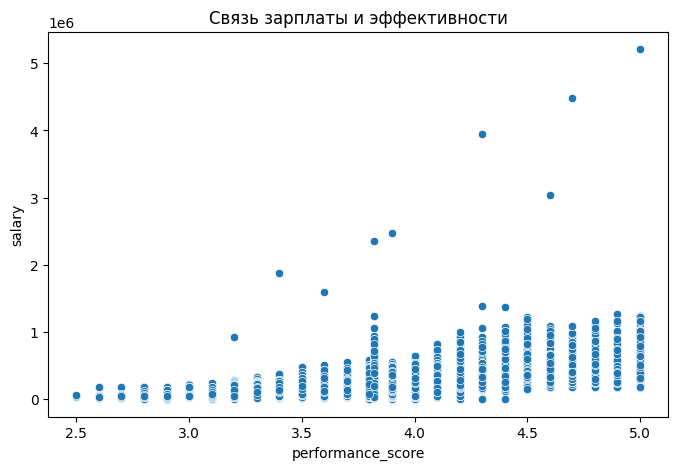

Корреляция: 0.623595868579724


In [ ]:
# 5. Связь зарплаты и эффективности
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='performance_score', y='salary')
plt.title('Связь зарплаты и эффективности')
plt.show()
print("Корреляция:", df_clean['salary'].corr(df_clean['performance_score']))

до abs(salary) было 0,53

In [ ]:
# 6. Эффективность по департаментам
df_clean.groupby('department')['performance_score'].mean().round(2)

,performance_score
department,
HR,3.82
IT,3.81
R&D,3.84
Консалтинг,3.80
Логистика,3.84
Маркетинг,3.83
Продажи,3.84
Производство,3.80
Финансы,3.83


In [ ]:
print("Наиболее оплачиваемый департамент:", df_clean.groupby('department')['salary'].mean().idxmax())
print("Самый эффективный департамент:", df_clean.groupby('department')['performance_score'].mean().idxmax())
print("Департамент с наибольшим количеством проектов:", df_clean.groupby('department')['projects_completed'].mean().idxmax())
print("Самый опытный департамент:", df_clean.groupby('department')['experience_years'].mean().idxmax())
print("Проблемные зоны (департамент с низкой оценкой):", df_clean.groupby('department')['performance_score'].mean().idxmin())

Наиболее оплачиваемый департамент: IT
Самый эффективный департамент: R&D
Департамент с наибольшим количеством проектов: Консалтинг
Самый опытный департамент: Консалтинг
Проблемные зоны (департамент с низкой оценкой): Юридический


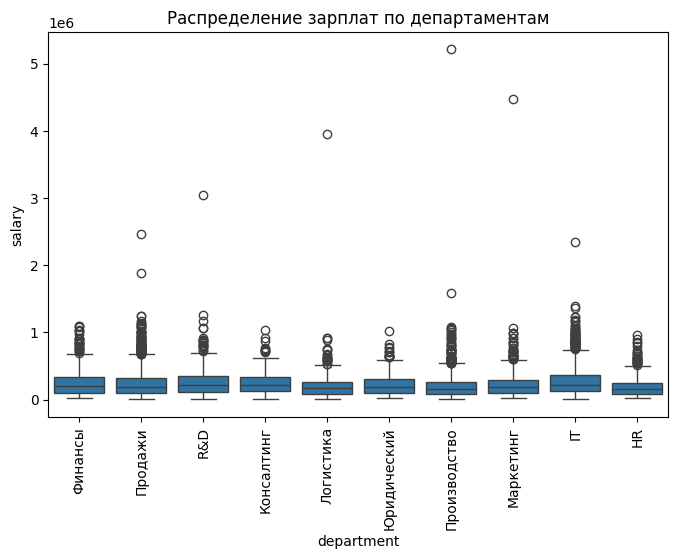

In [ ]:
# Распределение зарплат по департаментам
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='department', y='salary')
plt.title('Распределение зарплат по департаментам')
plt.xticks(rotation=90)
plt.show()

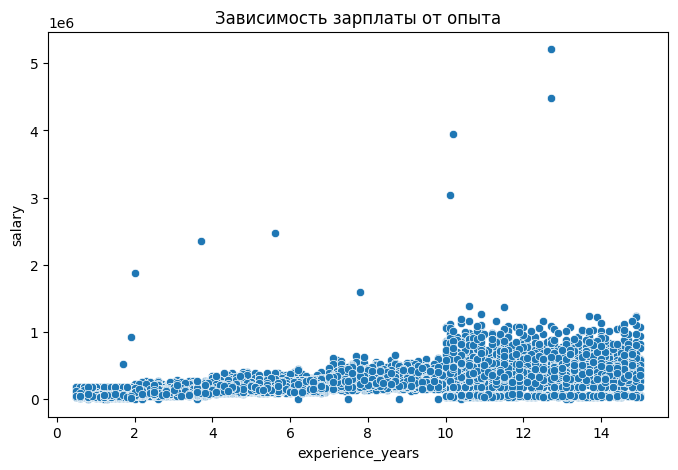

In [ ]:
# Зависимость зарплаты от опыта
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='experience_years', y='salary')
plt.title('Зависимость зарплаты от опыта')
plt.show()

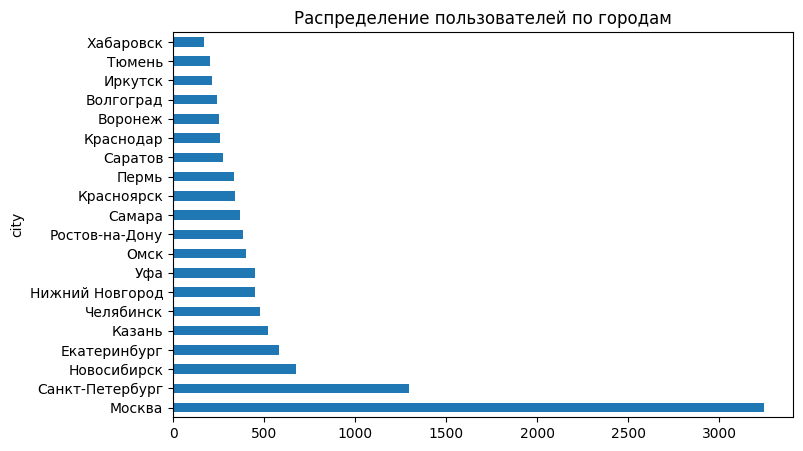

In [ ]:
# Распределение по городам

plt.figure(figsize=(8, 5))
df['city'].value_counts().plot(kind='barh')
plt.title('Распределение пользователей по городам')
plt.show()

Вопросы:
1. Какие инсайты можно получить из очищенных данных?
2. Как очистка данных повлияла на качество HR-анализа?
3. Какие бизнес-решения можно принять на основе этого анализа?
